In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [39]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df_4wj = pd.read_csv('/home/matrament/projects/master_thesis/data/literature_data/raw_dataset_laing2012.csv')
df_4wj['Coaxial'] = LE.fit_transform(df_4wj['Coaxial'])
df_4wj['Family'] = LE.fit_transform(df_4wj['Family'])
y_4wj = df_4wj['Family']
X_4wj = df_4wj.drop(columns=['Family', 'Coaxial','pdb'])
X_4wj

,|L1|,|L2|,|L3|,|L4|,"Min(|L2|,|L4|)","Min(|L1|,|L3|)",|L1'|,|L2'|,|L3'|,|L4'|,"ΔG(H1,H2)","ΔG(H2,H3)","ΔG(H3,H4)","ΔG(H4,H1)",A(L1),A(L2),A(L3),A(L4)
0,0,1,2,0,0,0,0,0,1,2.0,-3.4,0.7,6.9,-3.3,0.0,0,0,0.0
1,1,0,0,1,0,0,0,0,1,1.0,1.3,-3.3,-2.4,1.3,0.0,0,0,0.0
2,0,1,2,0,0,0,0,0,1,2.0,-3.4,0.8,6.9,-3.3,0.0,0,0,0.0
3,0,1,2,0,0,0,0,0,1,2.0,-3.4,0.8,6.9,-3.3,0.0,0,0,0.0
4,0,0,0,0,0,0,0,0,0,0.0,-0.9,-1.3,-2.1,-2.1,0.0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,2,3,2,5,3,2,2,2,3,5.0,6.9,6.6,6.9,6.0,2.0,2,0,2.0
61,2,3,2,2,2,2,2,2,2,3.0,6.9,6.6,6.9,6.9,0.0,0,0,0.0
62,3,4,0,3,3,0,0,3,3,4.0,6.6,6.3,-1.5,6.6,0.0,0,0,0.0
63,2,5,11,10,5,2,2,5,10,11.0,6.9,6.0,6.4,6.3,0.0,2,0,2.0


In [50]:
LE.classes_

array(['H', 'X', 'cH', 'cK', 'cL', 'cW', 'cX', 'π', 'ψ'], dtype=object)

In [40]:
print(f"Kształt danych: {X_4wj.shape}")
print(f"Liczba klas: {len(np.unique(y_4wj))}")
print(f"Rozkład klas:\n{pd.Series(y_4wj).value_counts()}")

Kształt danych: (65, 18)
Liczba klas: 9
Rozkład klas:
Family
2    14
3    12
4    12
0     8
8     7
5     4
1     3
6     3
7     2
Name: count, dtype: int64


In [3]:

X = pd.read_csv('/home/matrament/projects/master_thesis/X.csv') 
y = pd.read_csv('/home/matrament/projects/master_thesis/Y.csv') 
y = y.values.ravel()  # Flatten the array if necessary
X.drop(columns=['Family'], inplace=True)

In [4]:
print(f"Kształt danych: {X.shape}")
print(f"Liczba klas: {len(np.unique(y))}")
print(f"Rozkład klas:\n{pd.Series(y).value_counts()}")


Kształt danych: (112, 16)
Liczba klas: 3
Rozkład klas:
2    56
0    40
1    16
Name: count, dtype: int64


In [41]:
# X['A_max'] = X[['A(J12)',	'A(J23)','A(J31)']].max(axis=1)
# X['A_min'] = X[['A(J12)',	'A(J23)','A(J31)']].min(axis=1)
# X['G_max'] = X[['ΔG(H1,H2)',	'ΔG(H2,H3)',	'ΔG(H3,H1)']].max(axis=1)
# X['G_min'] = X[['ΔG(H1,H2)',	'ΔG(H2,H3)',	'ΔG(H3,H1)']].min(axis=1)

X_4wj['A_max'] = X_4wj[['A(L1)'	,'A(L2)',	'A(L3)'	,'A(L4)']].max(axis=1)
X_4wj['A_min'] = X_4wj[['A(L1)',	'A(L2)',	'A(L3)',	'A(L4)']].min(axis=1)
X_4wj['G_max'] = X_4wj[['ΔG(H1,H2)',	'ΔG(H2,H3)','ΔG(H3,H4)'	,'ΔG(H4,H1)']].max(axis=1)
X_4wj['G_min'] = X_4wj[['ΔG(H1,H2)',	'ΔG(H2,H3)','ΔG(H3,H4)'	,'ΔG(H4,H1)']].min(axis=1)


In [6]:
print(X.iloc[20])

|J12|         2.0
|J23|         4.0
|J31|         4.0
counts       14.0
ΔG(H1,H2)     6.9
ΔG(H2,H3)     6.3
ΔG(H3,H1)     6.3
A(J12)        0.0
A(J23)        0.0
A(J31)        0.0
minJ23        2.0
minJ31        2.0
minJ12        4.0
sort|J12|     2.0
sort|J23|     4.0
sort|J31|     4.0
A_max         0.0
A_min         0.0
G_max         6.9
G_min         6.3
Name: 20, dtype: float64


In [7]:
X

,|J12|,|J23|,|J31|,counts,"ΔG(H1,H2)","ΔG(H2,H3)","ΔG(H3,H1)",A(J12),A(J23),A(J31),minJ23,minJ31,minJ12,sort|J12|,sort|J23|,sort|J31|,A_max,A_min,G_max,G_min
0,6.0,9.0,19.0,11,5.7,6.1,7.0,0,4,3,6.0,6.0,9.0,6.0,9.0,19.0,4,0,7.0,5.7
1,6.0,10.0,20.0,14,5.7,6.3,7.0,0,3,3,6.0,6.0,10.0,6.0,10.0,20.0,3,0,7.0,5.7
2,6.0,9.0,19.0,13,5.7,6.1,7.0,0,4,3,6.0,6.0,9.0,6.0,9.0,19.0,4,0,7.0,5.7
3,2.0,14.0,4.0,11,6.9,6.6,6.3,0,0,3,2.0,2.0,4.0,2.0,4.0,14.0,3,0,6.9,6.3
4,2.0,15.0,4.0,14,6.9,6.7,6.3,0,2,2,2.0,2.0,4.0,2.0,4.0,15.0,2,0,6.9,6.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,1.0,5.0,8.0,10,1.1,6.0,6.0,0,0,2,1.0,1.0,5.0,1.0,5.0,8.0,2,0,6.0,1.1
108,2.0,10.0,1.0,1,6.9,6.3,0.6,0,2,0,1.0,2.0,1.0,1.0,2.0,10.0,2,0,6.9,0.6
109,1.0,9.0,3.0,1,0.6,6.1,6.6,0,3,0,1.0,1.0,3.0,1.0,3.0,9.0,3,0,6.6,0.6
110,1.0,8.0,2.0,1,0.6,6.0,6.9,0,3,0,1.0,1.0,2.0,1.0,2.0,8.0,3,0,6.9,0.6


In [ ]:
models = {
            'k-NN': KNeighborsClassifier(),
            'SVM': SVC(probability=True),
            'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
            'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', scale_pos_weight=1),
        }

param_grids = {
            'k-NN': {
                'n_neighbors': [3, 5, 7, 9, 11],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan'],
                'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                'leaf_size': [30, 40, 50],
            },
            'SVM': {
                'C': [0.1, 1, 10, 100],
                'kernel': ['rbf', 'linear', 'poly'],
                'gamma': ['scale', 'auto'],

            },
            'Random Forest': {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['auto', 'sqrt', 'log2'],
                'criterion': ['gini', 'entropy']
            },
            'Logistic Regression': {
                'C': [0.01, 0.1, 1, 10],
                'penalty': ['l2', 'elasticnet'],
                'solver': ['lbfgs', 'saga'],
                'max_iter': [100, 200, 500]
            },
            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0],
                'colsample_bytree': [0.8, 1.0],
                'gamma': [0, 0.1, 0.2],
            }
            # 'LightGBM': {
            #     'n_estimators': [100, 200],
            #     'learning_rate': [0.05, 0.1, 0.2],
            #     'num_leaves': [31, 63],
            #     'max_depth': [6, 9]
            # }
            # 'LightGBM': {
            #     'n_estimators': [50, 100, 200],
            #     'max_depth': [3, 6, 9, -1],  # -1 oznacza brak limitu
            #     'learning_rate': [0.01, 0.05, 0.1, 0.2],
            #     'num_leaves': [15, 31, 63, 127],  # powinno być < 2^max_depth
            #     'min_child_samples': [10, 20, 30],
            #     'subsample': [0.7, 0.8, 0.9, 1.0],
            #     'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            #     'reg_alpha': [0, 0.1, 0.5],  # L1 regularization
            #     'reg_lambda': [0, 0.1, 0.5]  # L2 regularization
            # }
        }

best_models = {}
        
for name, model in models.items():
    print(f"Dostrajanie hiperparametrów dla {name}...")

    
    grid_search = GridSearchCV(
        model, param_grids[name], 
        cv=10, scoring='balanced_accuracy', 
        n_jobs=-1, verbose=0
    )
    
    grid_search.fit(X, y)
    best_models[name] = grid_search.best_estimator_
    
    print(f"Najlepsze parametry dla {name}: {grid_search.best_params_}")
    print(f"Najlepszy wynik CV: {grid_search.best_score_:.4f}")
    print("-" * 50)


Dostrajanie hiperparametrów dla k-NN...


NameError: name 'X_4wj' is not defined

In [8]:
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score
# Ewaluacja modeli i zapisanie wyników
results = {}

for name, model in best_models.items():

    pipeline = Pipeline([
        ("smote", RandomOverSampler(random_state=42)),
        ("clf", model)
    ])


    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    cv_accuracy = cross_val_score(pipeline, X_4wj, y_4wj, cv=skf, scoring='accuracy')
    cv_balanced_accuracy = cross_val_score(pipeline, X_4wj, y_4wj, cv=skf, scoring='balanced_accuracy')
    cv_f1 = cross_val_score(pipeline, X_4wj, y_4wj, cv=skf, scoring='f1_weighted')
    # cv_roc = cross_val_score(pipeline, X_4wj, y_4wj, cv=skf, scoring='roc_auc_ovr')
    y_proba = cross_val_predict(pipeline, X_4wj, y_4wj, cv=skf, method="predict_proba")
    roc = roc_auc_score(y_4wj, y_proba, multi_class="ovr", average="weighted")

    results[name] = {

        'cv_mean': cv_accuracy.mean(),
        'cv_std': cv_accuracy.std(),
        'cv_balanced_accuracy_mean': cv_balanced_accuracy.mean(),
        'cv_balanced_accuracy_std': cv_balanced_accuracy.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std(),
        'cv_roc_mean': roc.mean(),
        'cv_roc_std': roc.std(),
    }
    
    print(f"\n{name} - Wyniki:")
    # print(f"Dokładność na zbiorze testowym: {accuracy:.4f}")
    print(f"Cross-validation Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std() * 2:.4f})")
    print(f"Cross-validation Balanced Accuracy: {cv_balanced_accuracy.mean():.4f} (+/- {cv_balanced_accuracy.std() * 2:.4f})")
    print(f"Cross-validation F1 Score: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")
    print(f"Cross-validation ROC AUC: {roc.mean():.4f} (+/- {roc.std() * 2:.4f})")
    print("-" * 80)

NameError: name 'best_models' is not defined

In [9]:
model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',  colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=50, subsample=0.8)
pipeline = Pipeline([
    ("smote", RandomOverSampler(random_state=42)),
    ("clf", model)
])
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
cv_accuracy.mean()

np.float64(0.825)

In [10]:
feature_map = {
  "|J12|" : "J12",
  "|J23|" : "J23",
  "|J31|" : "J31",
  "ΔG(H1,H2)":"ΔG(H1,H2)",
  "ΔG(H2,H3)": "ΔG(H2,H3)",
  "ΔG(H3,H1)" :"ΔG(H3,H1)",
  "A(J12)":"A(J12)",
  "A(J23)":"A(J23)",
  "A(J31)": "A(J31)",
  "minJ23": "min(J12,J31)",
  "minJ31": "min(J12,J23)",
  "minJ12": "min(J23,J31)",
  "sort|J12|": "J_min",
  "sort|J23|": "J_mid",
  "sort|J31|": "J_max",
}

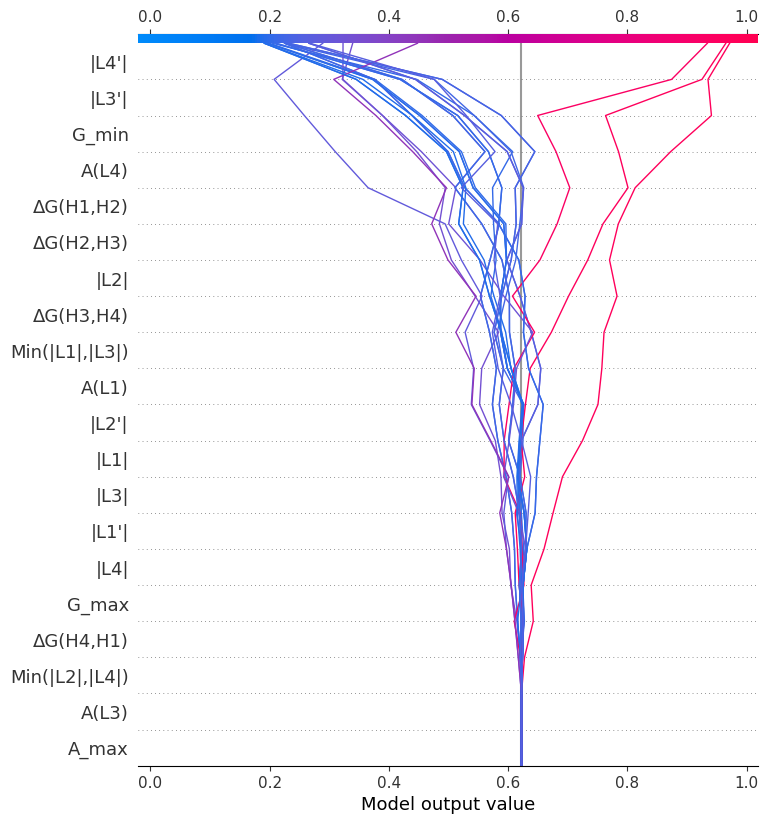

In [45]:
import shap

model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=50, subsample=0.8)
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_4wj, y_4wj)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

model.fit(X_train,y_train)

features = list(X_4wj.columns)
explainer = shap.TreeExplainer(model)
expected_value = explainer.expected_value
shap_values = explainer.shap_values(X_test)
# Plotting SHAP values for the first class
# Select a class (e.g., class 0)
class_idx = 0

shap.decision_plot(expected_value[0], shap_values[:,:,0], 
                   feature_names=features, link="logit")

In [44]:
explainer_xgb = shap.Explainer(model)
shap_values = explainer_xgb(X_test)

shap.plots.scatter(shap_values[:,"A(J31)",1])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

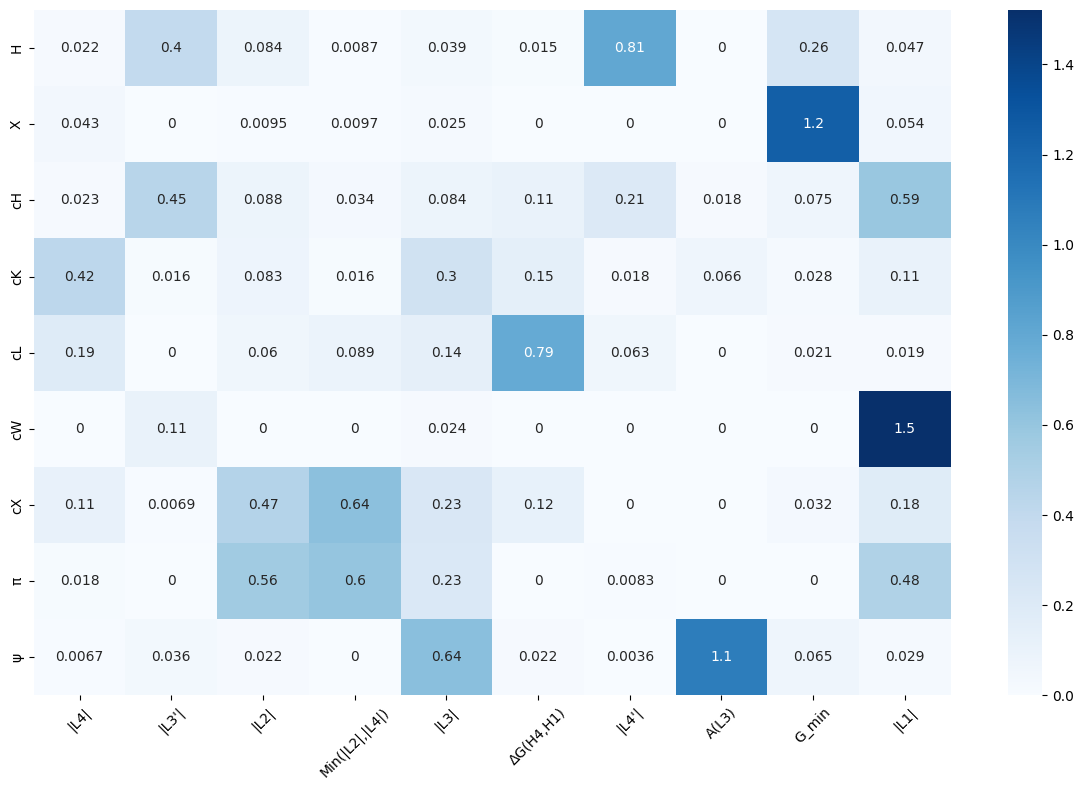

In [54]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)  # średnia po próbkach
top_features_idx = np.argsort(np.max(mean_abs_shap, axis=1))[-10:]  # top 10

plt.figure(figsize=(12, 8))
heatmap_data = mean_abs_shap[top_features_idx].T  # transponuj żeby klasy były na osi Y

sns.heatmap(heatmap_data, 
           xticklabels=[X_test.columns[i] for i in top_features_idx],
           yticklabels=['H', 'X', 'cH', 'cK', 'cL', 'cW', 'cX', 'π', 'ψ'],
           annot=True, 
           cmap='Blues',)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("heatmap_SHAP.svg", bbox_inches='tight')

In [ ]:
shap.decision_plot(expected_value[0], shap_values[:,:,0], 
                   feature_names=features)

plt.savefig("decision.png", dpi=700, bbox_inches='tight')
plt.close()


In [24]:
y_pred = model.predict(X_test)
print(y_test)
print(y_pred)

[1 0 1 0 2 2 2 1 0 0 0 2 2 2 1 1 0 2 1 2 2 1 0 0 0 2 1 2 1 1 0 0 2 1]
[1 0 1 0 2 2 2 1 0 0 0 2 2 1 1 1 0 2 1 2 2 1 0 0 0 2 1 2 1 1 0 0 2 1]


In [20]:
X_test

,J12,J23,J31,"ΔG(H1,H2)","ΔG(H2,H3)","ΔG(H3,H1)",A(J12),A(J23),A(J31),"min(J12,J31)","min(J12,J23)","min(J23,J31)",J_min,J_mid,J_max
20,2.0,4.0,4.0,6.9,6.3,6.3,0,0,0,2.0,2.0,4.0,2.0,4.0,4.0
100,5.0,12.0,1.0,6.0,6.5,0.6,2,2,0,1.0,5.0,1.0,1.0,5.0,12.0
11,3.0,8.0,3.0,6.6,6.0,6.6,2,0,0,3.0,3.0,3.0,3.0,3.0,8.0
47,0.0,4.0,3.0,-2.4,6.3,6.6,0,2,0,0.0,0.0,3.0,0.0,3.0,4.0
67,2.0,3.0,2.0,6.9,6.6,6.9,2,0,2,2.0,2.0,2.0,2.0,2.0,3.0
79,5.0,10.0,2.0,6.0,6.3,6.9,2,2,0,2.0,5.0,2.0,2.0,5.0,10.0
1,6.0,10.0,20.0,5.7,6.3,7.0,0,3,3,6.0,6.0,10.0,6.0,10.0,20.0
90,1.0,5.0,0.0,0.6,6.0,-3.3,0,3,0,0.0,1.0,0.0,0.0,1.0,5.0
65,6.0,2.0,4.0,5.7,6.9,6.3,0,0,0,4.0,2.0,2.0,2.0,4.0,6.0
27,4.0,1.0,2.0,6.3,0.6,6.9,2,0,2,2.0,1.0,1.0,1.0,2.0,4.0


In [16]:
# explainer = shap.TreeExplainer(model,X)
shap_values = explainer(X)
# shap_values.feature_names = [feature_map.get(f, f) for f in shap_values.feature_names]
shap.plots.waterfall(shap_values[20,:,0], max_display=10, show=False)
plt.savefig("waterfall_A.png", dpi=700, bbox_inches='tight')
plt.close()

shap.plots.waterfall(shap_values[20,:,1], max_display=10, show=False)
plt.savefig("waterfall_B.png", dpi=700, bbox_inches='tight')
plt.close()

shap.plots.waterfall(shap_values[20,:,2], max_display=10, show=False)
plt.savefig("waterfall_C.png", dpi=700, bbox_inches='tight')
plt.close()


In [17]:
from matplotlib.ticker import FormatStrFormatter

shap.plots.bar(shap_values[:,:,0].mean(0), max_display=10, show=False)
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.savefig("bar_A.png", dpi=700, bbox_inches='tight')
plt.close()

shap.plots.bar(shap_values[:,:,1].mean(0), max_display=10, show=False)
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.savefig("bar_B.png", dpi=700, bbox_inches='tight')
plt.close()

shap.plots.bar(shap_values[:,:,2].mean(0), max_display=10, show=False)
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.savefig("bar_C.png", dpi=700, bbox_inches='tight')
plt.close()


In [ ]:
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(model)
expected_value = explainer.expected_value
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values[:, :, 0], X_test, max_display=10, show=False)
plt.savefig("summary_A.png", dpi=700, bbox_inches='tight')
plt.close()

shap.summary_plot(shap_values[:, :, 1], X_test , max_display=10, show=False)
plt.savefig("summary_B.png", dpi=700, bbox_inches='tight')
plt.close()

shap.summary_plot(shap_values[:, :, 2], X_test, max_display=10, show=False)
plt.savefig("summary_C.png", dpi=700, bbox_inches='tight')
plt.close()

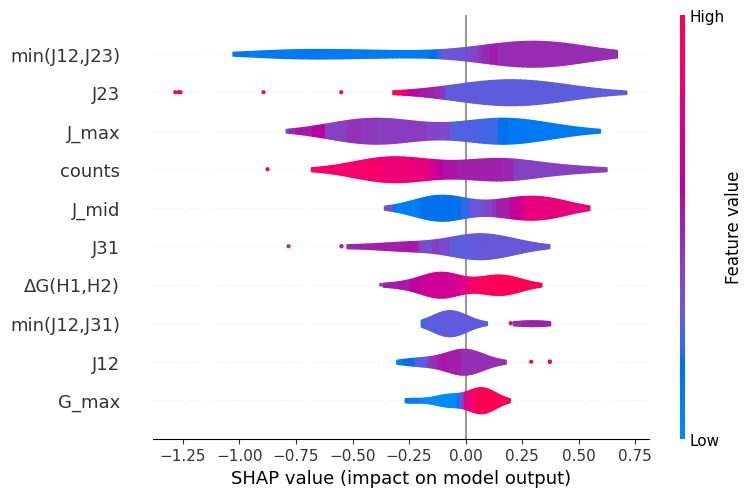

In [85]:
shap.plots.violin(shap_values[:, :, 1], X_test , max_display=10)



In [91]:
shap_values = explainer(X_test)
class_idx = 0  # or use any class index you want to visualize
shap.plots.bar(shap_values[:,:,class_idx], max_display=6, show=False)

<Axes: xlabel='mean(|SHAP value|)'>

In [38]:
features = list(X.columns)
features = [feature_map.get(f, f) for f in features]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test) 
shap.summary_plot(shap_values, X_test, max_display=10, feature_names=features, class_names=['Family A', 'Family B', 'Family C'] , show=False )
plt.savefig("summary_plot.png", dpi=700, bbox_inches='tight')
plt.close()